In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from dnsmex.local import localify
from utils import is_in_cdr, sort_antibody_sites, GERMLINE_PATH_DICTIONARY, add_cdr_shading
from dnsmex.koenig_helper import KoenigDataset



In [2]:
# koenig concensus seq, IGHV3
koenig_anarci_chothia = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/koenig/koenig_concensus_anarci_output_H_chothia.csv')
koenig_anarci_chothia = koenig_anarci_chothia.T

# Find the position where index equals 1
start_pos = koenig_anarci_chothia.index.get_loc('1')

# Keep everything from that position onward
koenig_anarci_chothia = koenig_anarci_chothia.iloc[start_pos:]

koenig_anarci_chothia = koenig_anarci_chothia.reset_index()
koenig_anarci_chothia.index = koenig_anarci_chothia.index + 1
koenig_anarci_chothia.rename(columns={'index': 'chothia_site'}, inplace=True)
koenig_anarci_chothia.drop(columns=[0], inplace=True)
koenig_anarci_chothia = koenig_anarci_chothia.reset_index()
koenig_anarci_chothia.rename(columns={'index': 'koenig_index'}, inplace=True)
koenig_anarci_chothia

,koenig_index,chothia_site
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
...,...,...
115,116,109
116,117,110
117,118,111
118,119,112


In [3]:
## with Koenig dataframe


binding_dataset = KoenigDataset(
    localify("DATA_DIR/FLAb/data/binding/Koenig2017_g6_Kd.csv"),
    fitness_column="fitness",
    fitness_label="binding enrichment ratio",
    log_transform=True,
)

expr_dataset = KoenigDataset(
    localify("DATA_DIR/FLAb/data/expression/Koenig2017_g6_er.csv"), 
    fitness_column="fitness",
    fitness_label="binding enrichment ratio",
    log_transform=True,
    )

binding_df = pd.merge(binding_dataset.heavy_df, koenig_anarci_chothia.rename(columns={'koenig_index':'site'}), on='site')
expression_df = pd.merge(expr_dataset.heavy_df, koenig_anarci_chothia.rename(columns={'koenig_index':'site'}), on='site')

binding_df['log_fitness'] = np.log(binding_df.fitness)
expression_df['log_fitness'] = np.log(expression_df.fitness)



In [4]:
## aggregate fitness per site, as the mutations present do not show all entrenched possibilities

In [5]:
fitness_df = pd.merge(binding_df.groupby('chothia_site').log_fitness.mean().reset_index(), expression_df.groupby('chothia_site').log_fitness.mean().reset_index(), on='chothia_site', suffixes=('_binding', '_expression'))
fitness_df

,chothia_site,log_fitness_binding,log_fitness_expression
0,10,-0.327888,0.229007
1,100,-2.138957,-1.320900
2,100A,-1.225351,-0.134102
3,100B,-3.666193,-0.469191
4,100C,-0.976824,-0.264573
...,...,...,...
114,95,-3.198672,-0.284015
115,96,-2.844174,-0.239277
116,97,-1.902043,0.065033
117,98,-3.472526,0.188595


In [6]:
entrenched_within = pd.read_csv('_output/entrenchment_analysis/chothia/entrenched_aa_sites_within_IGHV3.csv', dtype={'site':str})
entrenched_between = pd.read_csv('_output/entrenchment_analysis/chothia/entrenched_aa_sites_IGHV1_vs_IGHV3.csv', dtype={'site':str})    
entrenched_between = entrenched_between[entrenched_between['v_family']=='IGHV3']



Statistical test results (Mann-Whitney U test, non-entrenched vs entrenched):
Within V family - Binding: p = 7.20e-03, r = -0.681, n = (114, 5)
Within V family - Expression: p = 8.02e-01, r = -0.070, n = (114, 5)
Between V families - Binding: p = 2.57e-02, r = -0.468, n = (111, 8)
Between V families - Expression: p = 5.77e-01, r = -0.122, n = (111, 8)


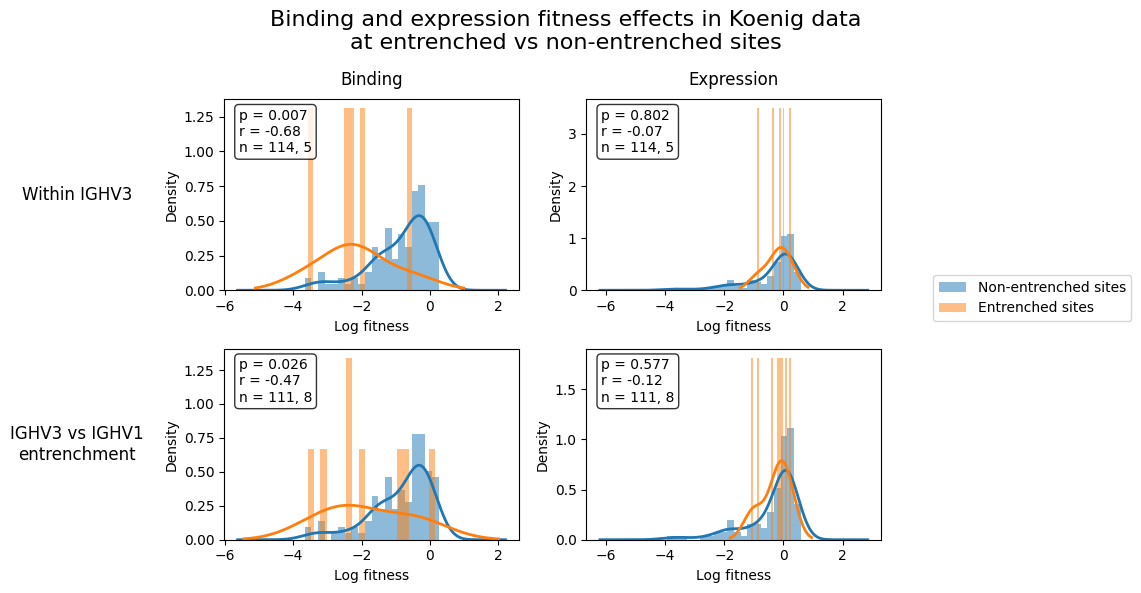

In [7]:
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Get first two colors from tab10
colors = plt.cm.tab10.colors
color_non_entrenched = colors[0]
color_entrenched = colors[1]

# Row 1: Within IGHV3 entrenched
entrenched_fitness_df = fitness_df[fitness_df.chothia_site.isin(entrenched_within.site)]
non_entrenched_fitness_df = fitness_df[~fitness_df.chothia_site.isin(entrenched_within.site)]

# Binding fitness
non_entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='Non-entrenched sites', density=True, color=color_non_entrenched)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
non_entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_non_entrenched, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_entrenched, legend=False)
axes[0,0].set_xlabel('Log fitness')
axes[0,0].set_ylabel('Density')

# Statistical test - binding (within)
stat_binding_within, p_binding_within = mannwhitneyu(
    non_entrenched_fitness_df.log_fitness_binding.dropna(), 
    entrenched_fitness_df.log_fitness_binding.dropna(),
    alternative='two-sided'
)
# Calculate effect size (rank-biserial correlation)
n1_binding_within = len(non_entrenched_fitness_df.log_fitness_binding.dropna())
n2_binding_within = len(entrenched_fitness_df.log_fitness_binding.dropna())
r_binding_within = 1 - (2*stat_binding_within) / (n1_binding_within * n2_binding_within)

# Add p-value, effect size, and sample sizes to plot
p_text = f'p = {p_binding_within:.2e}' if p_binding_within < 0.001 else f'p = {p_binding_within:.3f}'
effect_text = f'r = {r_binding_within:.2f}'
n_text = f'n = {n1_binding_within}, {n2_binding_within}'
combined_text = f'{p_text}\n{effect_text}\n{n_text}'
axes[0,0].text(0.05, 0.95, combined_text, transform=axes[0,0].transAxes, 
               fontsize=10, va='top', ha='left', 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Expression fitness
non_entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='Non-entrenched sites', density=True, color=color_non_entrenched)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
non_entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_non_entrenched, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_entrenched, legend=False)
axes[0,1].set_xlabel('Log fitness')
axes[0,1].set_ylabel('Density')

# Statistical test - expression (within)
stat_expr_within, p_expr_within = mannwhitneyu(
    non_entrenched_fitness_df.log_fitness_expression.dropna(), 
    entrenched_fitness_df.log_fitness_expression.dropna(),
    alternative='two-sided'
)
n1_expr_within = len(non_entrenched_fitness_df.log_fitness_expression.dropna())
n2_expr_within = len(entrenched_fitness_df.log_fitness_expression.dropna())
r_expr_within = 1 - (2*stat_expr_within) / (n1_expr_within * n2_expr_within)

p_text = f'p = {p_expr_within:.2e}' if p_expr_within < 0.001 else f'p = {p_expr_within:.3f}'
effect_text = f'r = {r_expr_within:.2f}'
n_text = f'n = {n1_expr_within}, {n2_expr_within}'
combined_text = f'{p_text}\n{effect_text}\n{n_text}'
axes[0,1].text(0.05, 0.95, combined_text, transform=axes[0,1].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Row 2: Between IGHV1 and IGHV3
entrenched_fitness_df = fitness_df[fitness_df.chothia_site.isin(entrenched_between.site)]
non_entrenched_fitness_df = fitness_df[~fitness_df.chothia_site.isin(entrenched_between.site)]

# Binding fitness
non_entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='Non-entrenched sites', density=True, color=color_non_entrenched)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
non_entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_non_entrenched, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_entrenched, legend=False)
axes[1,0].set_xlabel('Log fitness')
axes[1,0].set_ylabel('Density')

# Statistical test - binding (between)
stat_binding_between, p_binding_between = mannwhitneyu(
    non_entrenched_fitness_df.log_fitness_binding.dropna(), 
    entrenched_fitness_df.log_fitness_binding.dropna(),
    alternative='two-sided'
)
n1_binding_between = len(non_entrenched_fitness_df.log_fitness_binding.dropna())
n2_binding_between = len(entrenched_fitness_df.log_fitness_binding.dropna())
r_binding_between = 1 - (2*stat_binding_between) / (n1_binding_between * n2_binding_between)

p_text = f'p = {p_binding_between:.2e}' if p_binding_between < 0.001 else f'p = {p_binding_between:.3f}'
effect_text = f'r = {r_binding_between:.2f}'
n_text = f'n = {n1_binding_between}, {n2_binding_between}'
combined_text = f'{p_text}\n{effect_text}\n{n_text}'
axes[1,0].text(0.05, 0.95, combined_text, transform=axes[1,0].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Expression fitness
non_entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='Non-entrenched sites', density=True, color=color_non_entrenched)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
non_entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_non_entrenched, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_entrenched, legend=False)
axes[1,1].set_xlabel('Log fitness')
axes[1,1].set_ylabel('Density')

# Statistical test - expression (between)
stat_expr_between, p_expr_between = mannwhitneyu(
    non_entrenched_fitness_df.log_fitness_expression.dropna(), 
    entrenched_fitness_df.log_fitness_expression.dropna(),
    alternative='two-sided'
)
n1_expr_between = len(non_entrenched_fitness_df.log_fitness_expression.dropna())
n2_expr_between = len(entrenched_fitness_df.log_fitness_expression.dropna())
r_expr_between = 1 - (2*stat_expr_between) / (n1_expr_between * n2_expr_between)

p_text = f'p = {p_expr_between:.2e}' if p_expr_between < 0.001 else f'p = {p_expr_between:.3f}'
effect_text = f'r = {r_expr_between:.2f}'
n_text = f'n = {n1_expr_between}, {n2_expr_between}'
combined_text = f'{p_text}\n{effect_text}\n{n_text}'
axes[1,1].text(0.05, 0.95, combined_text, transform=axes[1,1].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Column titles
axes[0,0].set_title('Binding', fontsize=12, pad=10)
axes[0,1].set_title('Expression', fontsize=12, pad=10)

# Row titles (on the left side, horizontal)
axes[0,0].text(-0.5, 0.5, 'Within IGHV3', transform=axes[0,0].transAxes, 
               fontsize=12, va='center', ha='center')
axes[1,0].text(-0.5, 0.5, 'IGHV3 vs IGHV1\nentrenchment', transform=axes[1,0].transAxes, 
               fontsize=12, va='center', ha='center')

# Get only histogram handles (first 2) from legend
handles, labels = axes[0,0].get_legend_handles_labels()
legend = fig.legend(handles[:2], labels[:2], loc='center left', bbox_to_anchor=(0.9, 0.5))

# Remove individual legends
for ax_row in axes:
    for ax in ax_row:
        if ax.get_legend():
            ax.legend().remove()

fig.suptitle('Binding and expression fitness effects in Koenig data\nat entrenched vs non-entrenched sites', fontsize=16)
plt.tight_layout()
fig.subplots_adjust(left=0.12, right=0.85)  # Make room for row titles and legend

# Print summary of statistical tests
print("\nStatistical test results (Mann-Whitney U test, non-entrenched vs entrenched):")
print(f"Within V family - Binding: p = {p_binding_within:.2e}, r = {r_binding_within:.3f}, n = ({n1_binding_within}, {n2_binding_within})")
print(f"Within V family - Expression: p = {p_expr_within:.2e}, r = {r_expr_within:.3f}, n = ({n1_expr_within}, {n2_expr_within})")
print(f"Between V families - Binding: p = {p_binding_between:.2e}, r = {r_binding_between:.3f}, n = ({n1_binding_between}, {n2_binding_between})")
print(f"Between V families - Expression: p = {p_expr_between:.2e}, r = {r_expr_between:.3f}, n = ({n1_expr_between}, {n2_expr_between})")

plt.show()
fig.savefig('figures/koenig_binding_expression_fitness_entrenchment_histograms.png', dpi=800, bbox_inches='tight')

In [8]:
### individual mutations

fitness_df = pd.merge(binding_df, expression_df, on=['chothia_site', 'site', 'difference', 'aa'], suffixes=('_binding', '_expression'))
fitness_df['amino_acid'] = fitness_df.difference.str[0]
fitness_df.rename(columns={'aa':'target_amino_acid'}, inplace=True)
fitness_df


,heavy_binding,light_binding,fitness_binding,heavy_differences_binding,light_differences_binding,heavy_difference_count_binding,light_difference_count_binding,difference_count_binding,difference,site,...,heavy_expression,light_expression,fitness_expression,heavy_differences_expression,light_differences_expression,heavy_difference_count_expression,light_difference_count_expression,difference_count_expression,log_fitness_expression,amino_acid
0,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,3.620218,[V2A],[],1,0,1,V2A,2,...,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.819679,[V2A],[],1,0,1,-0.198843,V
1,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.142127,[V2C],[],1,0,1,V2C,2,...,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.328397,[V2C],[],1,0,1,-1.113532,V
2,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,2.378990,[V2D],[],1,0,1,V2D,2,...,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.585834,[V2D],[],1,0,1,0.461110,V
3,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.578943,[V2E],[],1,0,1,V2E,2,...,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.806183,[V2E],[],1,0,1,0.591216,V
4,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.806596,[V2F],[],1,0,1,V2F,2,...,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.452152,[V2F],[],1,0,1,0.373046,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2256,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,2.324930,[S120R],[],1,0,1,S120R,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.780243,[S120R],[],1,0,1,0.576750,S
2257,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.376044,[S120T],[],1,0,1,S120T,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.461977,[S120T],[],1,0,1,0.379790,S
2258,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.835231,[S120V],[],1,0,1,S120V,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.177392,[S120V],[],1,0,1,0.163302,S
2259,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.326943,[S120W],[],1,0,1,S120W,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.129685,[S120W],[],1,0,1,0.121939,S


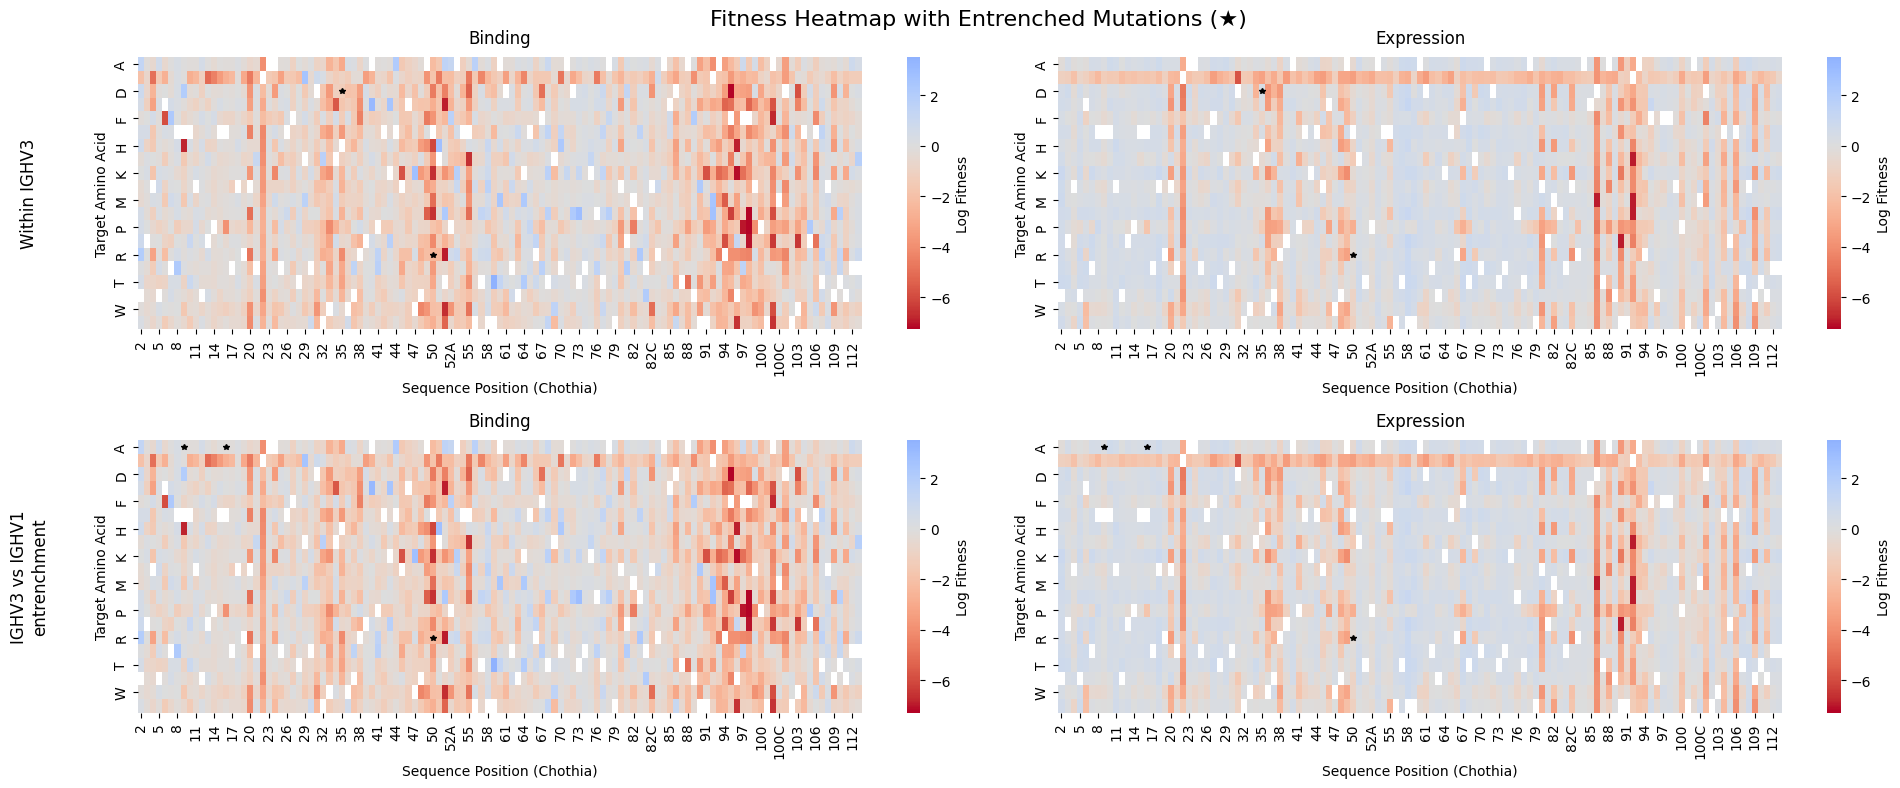

In [9]:
# Fitness Heatmap with Entrenched Mutations marked with stars
# 2x2 grid: rows = entrenchment type (within/between), columns = fitness type (binding/expression)

from utils import sort_antibody_sites

# Create pivot tables for heatmaps
heatmap_binding = fitness_df.pivot_table(
    index='target_amino_acid',
    columns='chothia_site',
    values='log_fitness_binding'
)
heatmap_expression = fitness_df.pivot_table(
    index='target_amino_acid',
    columns='chothia_site',
    values='log_fitness_expression'
)

# Sort columns by antibody site order
sorted_sites = sort_antibody_sites(heatmap_binding.columns.tolist())
heatmap_binding = heatmap_binding[sorted_sites]
heatmap_expression = heatmap_expression[sorted_sites]

# Sort amino acids alphabetically for consistent y-axis
aa_order = sorted(heatmap_binding.index.tolist())
heatmap_binding = heatmap_binding.reindex(aa_order)
heatmap_expression = heatmap_expression.reindex(aa_order)

# Get entrenched positions for marking with stars
entrenched_within_positions = pd.merge(
    fitness_df, 
    entrenched_within.rename(columns={'site':'chothia_site'}), 
    on=['chothia_site', 'amino_acid', 'target_amino_acid']
)[['chothia_site', 'target_amino_acid']].drop_duplicates()

entrenched_between_positions = pd.merge(
    fitness_df, 
    entrenched_between.rename(columns={'site':'chothia_site'}), 
    on=['chothia_site', 'amino_acid', 'target_amino_acid']
)[['chothia_site', 'target_amino_acid']].drop_duplicates()

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(20, 8))

# Color limits (shared across all heatmaps)
vmin = min(heatmap_binding.min().min(), heatmap_expression.min().min())
vmax = max(heatmap_binding.max().max(), heatmap_expression.max().max())

def plot_heatmap_with_stars(ax, heatmap_data, entrenched_positions, title):
    """Plot heatmap and overlay stars at entrenched positions."""
    sns.heatmap(heatmap_data, ax=ax, cmap='coolwarm_r', center=0,
                vmin=vmin, vmax=vmax,
                cbar_kws={'label': 'Log Fitness'})
    
    # Add stars at entrenched positions
    for _, row in entrenched_positions.iterrows():
        site = row['chothia_site']
        aa = row['target_amino_acid']
        
        if site in heatmap_data.columns and aa in heatmap_data.index:
            x_pos = list(heatmap_data.columns).index(site) + 0.5
            y_pos = list(heatmap_data.index).index(aa) + 0.5
            ax.plot(x_pos, y_pos, marker='*', color='black', markersize=4)
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('Sequence Position (Chothia)')
    ax.set_ylabel('Target Amino Acid')

# Row 1: Within IGHV3 entrenchment
plot_heatmap_with_stars(axes[0, 0], heatmap_binding, entrenched_within_positions, 'Binding')
plot_heatmap_with_stars(axes[0, 1], heatmap_expression, entrenched_within_positions, 'Expression')

# Row 2: Between IGHV1 vs IGHV3 entrenchment
plot_heatmap_with_stars(axes[1, 0], heatmap_binding, entrenched_between_positions, 'Binding')
plot_heatmap_with_stars(axes[1, 1], heatmap_expression, entrenched_between_positions, 'Expression')

# Row titles
axes[0, 0].text(-0.15, 0.5, 'Within IGHV3', transform=axes[0, 0].transAxes, 
                fontsize=12, va='center', ha='center', rotation=90)
axes[1, 0].text(-0.15, 0.5, 'IGHV3 vs IGHV1\nentrenchment', transform=axes[1, 0].transAxes, 
                fontsize=12, va='center', ha='center', rotation=90)

fig.suptitle('Fitness Heatmap with Entrenched Mutations (★)', fontsize=16)
plt.tight_layout()
fig.subplots_adjust(left=0.08, top=0.92)
fig.show()
fig.savefig('figures/koenig_fitness_heatmap_entrenched.png', dpi=300, bbox_inches='tight')